In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from src.data.preprocessing import fill_missing_values, fit_preprocess, transform
from src.features.build_features import build_features
from imblearn.under_sampling import RandomUnderSampler

The target variable, 'SeriousDlqin2yrs', exhibits a significant class imbalance. This imbalance introduces a strong bias toward the majority class, leading to misleading performance metrics such as high accuracy, while failing to correctly identify the minority class.

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64


<Axes: xlabel='SeriousDlqin2yrs', ylabel='count'>

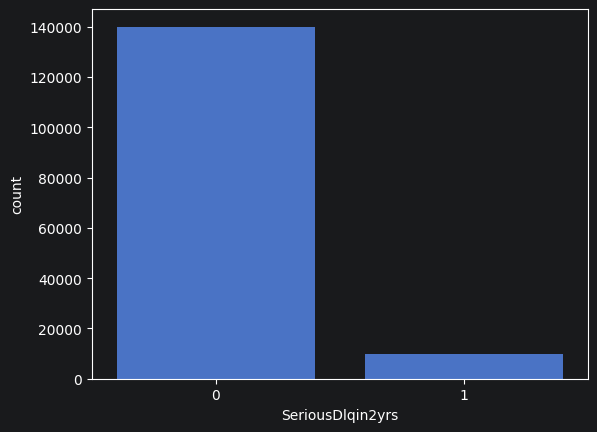

In [39]:
df = pd.read_csv("../data/raw/cs-training.csv")
print(df['SeriousDlqin2yrs'].value_counts())
sns.countplot(x=df['SeriousDlqin2yrs'])

There are several well-established techniques used to address class imbalance in binary classification problems. These approaches include **random undersampling**, which reduces the size of the majority class, **random oversampling**, which duplicates minority class samples, and **SMOTE (Synthetic Minority Over-sampling Technique)**, which generates synthetic minority samples by interpolating between existing observations.

In addition, cost-sensitive learning methods, such as **class weighting** or the **scale_pos_weight** parameter in gradient boosting models, adjust the learning process without modifying the original data distribution. Each method involves trade-offs between information loss, overfitting risk, and model complexity.

In this project, a combined resampling strategy was selected, consisting of SMOTE applied to the minority class together with mild undersampling of the majority class. This approach was chosen to achieve a better balance between classes while minimizing information loss from the majority class and reducing the overfitting risk associated with naive oversampling.

In [40]:
df = df.drop('Unnamed: 0', axis=1)
df = fill_missing_values(df)

X, y = df.drop('SeriousDlqin2yrs', axis=1), df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.2, stratify=y , random_state=42)

median_age, working_mean_income, senior_mean_income = fit_preprocess(X_train)

X_train = transform(X_train, median_age, working_mean_income, senior_mean_income)
X_test = transform(X_test, median_age, working_mean_income, senior_mean_income)

X_train = build_features(X_train)
X_test = build_features(X_test)

smote = SMOTE(sampling_strategy=0.4, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_train_resampled_twice, y_train_resampled_twice = rus.fit_resample(X_train_resampled, y_train_resampled)

print("Original distribution:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))
print("After SMOTE + RUS:", Counter(y_train_resampled_twice))
print("Test distribution:", Counter(y_test))

Original distribution: Counter({0: 111979, 1: 8021})
After SMOTE: Counter({0: 111979, 1: 44791})
After SMOTE + RUS: Counter({0: 89582, 1: 44791})
Test distribution: Counter({0: 27995, 1: 2005})


In [41]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,120000.0,6.128916,253.361490,0.0,0.029593,0.153318,0.557832,50708.0
age,120000.0,52.288275,14.770503,21.0,41.000000,52.000000,63.000000,109.0
DebtRatio,120000.0,352.271245,2093.709509,0.0,0.175330,0.366194,0.860833,329664.0
MonthlyIncome,120000.0,6653.809526,13028.023900,0.0,3900.000000,6577.500000,7400.000000,3008750.0
NumberOfDependents,120000.0,0.737592,1.107299,0.0,0.000000,0.000000,1.000000,20.0
WasEverLate,120000.0,0.202567,0.401914,0.0,0.000000,0.000000,0.000000,1.0
DebtOnAssets,120000.0,0.742492,0.437264,0.0,0.000000,1.000000,1.000000,1.0


In [42]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 120000 entries, 57836 to 80530
Data columns (total 7 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RevolvingUtilizationOfUnsecuredLines  120000 non-null  float64
 1   age                                   120000 non-null  int64  
 2   DebtRatio                             120000 non-null  float64
 3   MonthlyIncome                         120000 non-null  float64
 4   NumberOfDependents                    120000 non-null  int64  
 5   WasEverLate                           120000 non-null  int64  
 6   DebtOnAssets                          120000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 7.3 MB


In [43]:
X_train_resampled.describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,156770.0,5.631227,227.877421,0.0,0.049430,0.288427,0.776813,50708.0
age,156770.0,50.692581,14.465350,21.0,40.000000,50.000000,61.000000,109.0
DebtRatio,156770.0,333.281309,1898.950971,0.0,0.189808,0.382341,0.840506,329664.0
MonthlyIncome,156770.0,6459.107458,11719.078973,0.0,3692.000000,6201.887186,7083.000000,3008750.0
NumberOfDependents,156770.0,0.713019,1.065962,0.0,0.000000,0.000000,1.000000,20.0
WasEverLate,156770.0,0.264432,0.441032,0.0,0.000000,0.000000,1.000000,1.0
DebtOnAssets,156770.0,0.680251,0.466381,0.0,0.000000,1.000000,1.000000,1.0


In [44]:
X_train_resampled_twice.info()

<class 'pandas.DataFrame'>
Index: 134373 entries, 104181 to 156769
Data columns (total 7 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RevolvingUtilizationOfUnsecuredLines  134373 non-null  float64
 1   age                                   134373 non-null  int64  
 2   DebtRatio                             134373 non-null  float64
 3   MonthlyIncome                         134373 non-null  float64
 4   NumberOfDependents                    134373 non-null  int64  
 5   WasEverLate                           134373 non-null  int64  
 6   DebtOnAssets                          134373 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 8.2 MB


<Axes: xlabel='SeriousDlqin2yrs', ylabel='count'>

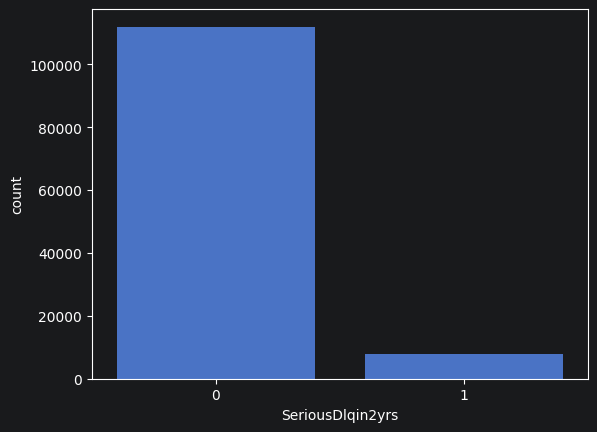

In [45]:
sns.countplot(x=y_train)

<Axes: xlabel='count', ylabel='SeriousDlqin2yrs'>

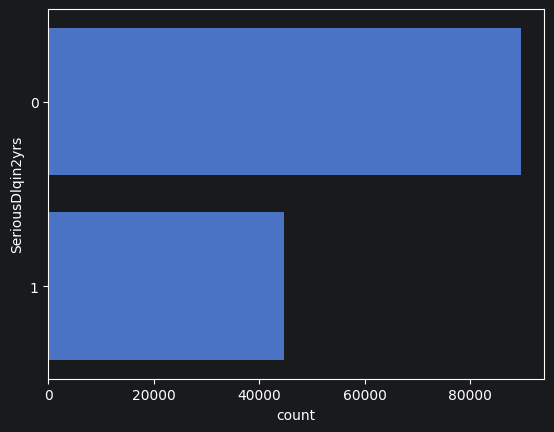

In [46]:
sns.countplot(y=y_train_resampled_twice)

After applying SMOTE and controlled undersampling, the dataset was validated to ensure that no data integrity issues were introduced. Feature distributions remained stable and no missing values were generated, confirming that the preprocessing pipeline preserved the original data structure.

The class distribution was successfully rebalanced, reducing the strong majority-class bias and improving the model’s ability to learn minority class patterns. This resampling strategy was evaluated as part of the modeling pipeline. However, depending on the algorithm, particularly gradient boosting models, class weighting or built-in imbalance handling may be a more stable alternative to altering the original data distribution.